<a href="https://colab.research.google.com/github/sanyamtyagi229/Python-Logic-Lab/blob/main/weather_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
lat, lon = 30.9010, 75.8573

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data["daily"])
df["time"] = pd.to_datetime(df["time"])
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2023-01-01,17.1,6.4,0.0
1,2023-01-02,15.6,4.0,0.0
2,2023-01-03,15.2,5.2,0.0
3,2023-01-04,16.0,5.6,0.0
4,2023-01-05,14.6,5.7,0.0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   time                365 non-null    datetime64[ns]
 1   temperature_2m_max  365 non-null    float64       
 2   temperature_2m_min  365 non-null    float64       
 3   precipitation_sum   365 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 11.5 KB


,0
time,0
temperature_2m_max,0
temperature_2m_min,0
precipitation_sum,0


In [4]:

df["month"] = df["time"].dt.month

hottest_day = df.loc[df["temperature_2m_max"].idxmax()]
print("Hottest day:", hottest_day["time"].date(), "->", hottest_day["temperature_2m_max"], "°C")
coldest_day = df.loc[df["temperature_2m_min"].idxmin()]
print("Coldest day:", coldest_day["time"].date(), "->", coldest_day["temperature_2m_min"], "°C")
monthly_rain = df.groupby("month")["precipitation_sum"].sum()
print("\nTotal rainfall by month:\n", monthly_rain)
print("\nRainiest month:", monthly_rain.idxmax())

monthly_avg_temp = df.groupby("month")["temperature_2m_max"].mean()
print("\nAverage max temp by month:\n", monthly_avg_temp)
hot_days = df[df["temperature_2m_max"] > 40]
print("\nNumber of days above 40°C:", len(hot_days))
temp_std = np.std(df["temperature_2m_max"])
print("\nStd deviation of daily max temp:", round(temp_std, 2), "°C")

Hottest day: 2023-05-22 -> 42.4 °C
Coldest day: 2023-01-17 -> 1.8 °C

Total rainfall by month:
 month
1      49.0
2       4.1
3      81.0
4      25.8
5     113.1
6      51.6
7     211.9
8      92.8
9      80.4
10     18.5
11     11.7
12      0.0
Name: precipitation_sum, dtype: float64

Rainiest month: 7

Average max temp by month:
 month
1     16.625806
2     23.628571
3     26.764516
4     32.083333
5     34.383871
6     35.820000
7     32.800000
8     33.583871
9     33.476667
10    30.803226
11    26.273333
12    21.038710
Name: temperature_2m_max, dtype: float64

Number of days above 40°C: 3

Std deviation of daily max temp: 6.34 °C


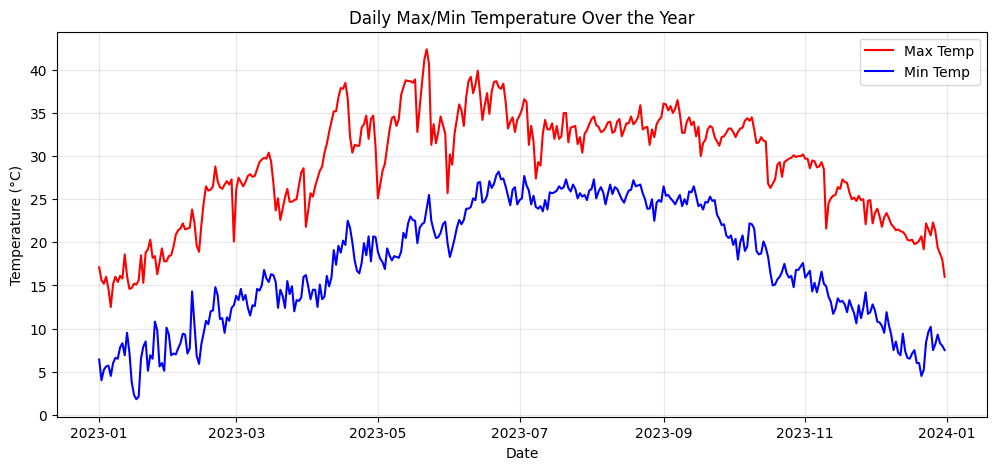

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["time"], df["temperature_2m_max"], label="Max Temp", color="red")
plt.plot(df["time"], df["temperature_2m_min"], label="Min Temp", color="blue")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Max/Min Temperature Over the Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

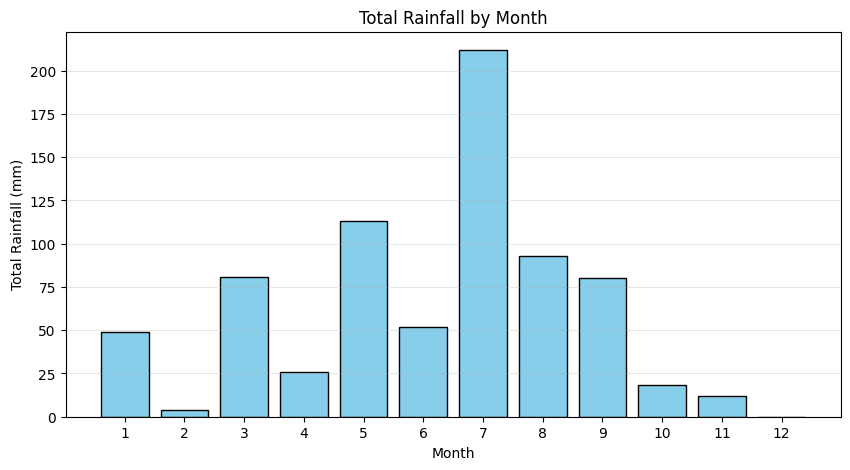

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_rain.index, monthly_rain.values, color="skyblue", edgecolor="black")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.title("Total Rainfall by Month")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3, axis="y")
plt.show()

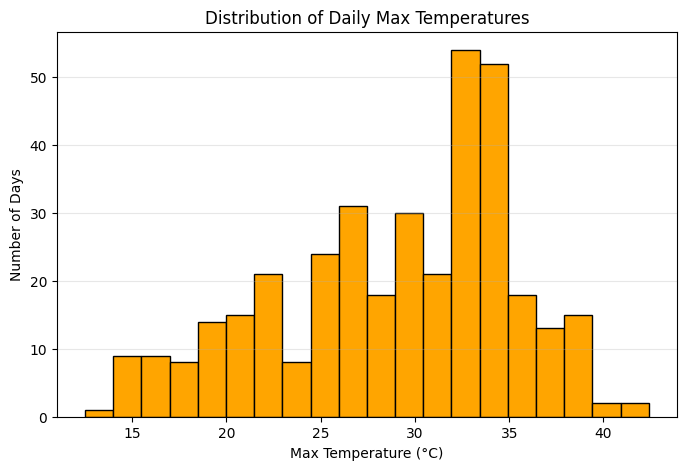

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["temperature_2m_max"], bins=20, color="orange", edgecolor="black")
plt.xlabel("Max Temperature (°C)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Max Temperatures")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

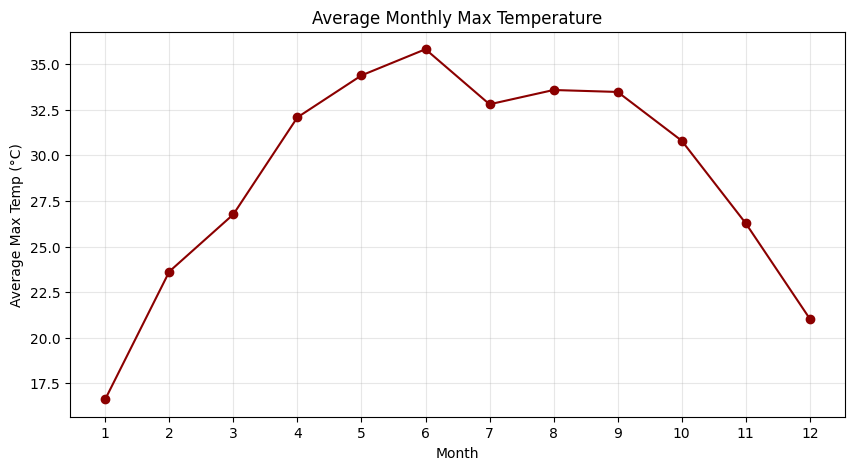

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg_temp.index, monthly_avg_temp.values, marker="o", color="darkred")
plt.xlabel("Month")
plt.ylabel("Average Max Temp (°C)")
plt.title("Average Monthly Max Temperature")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()